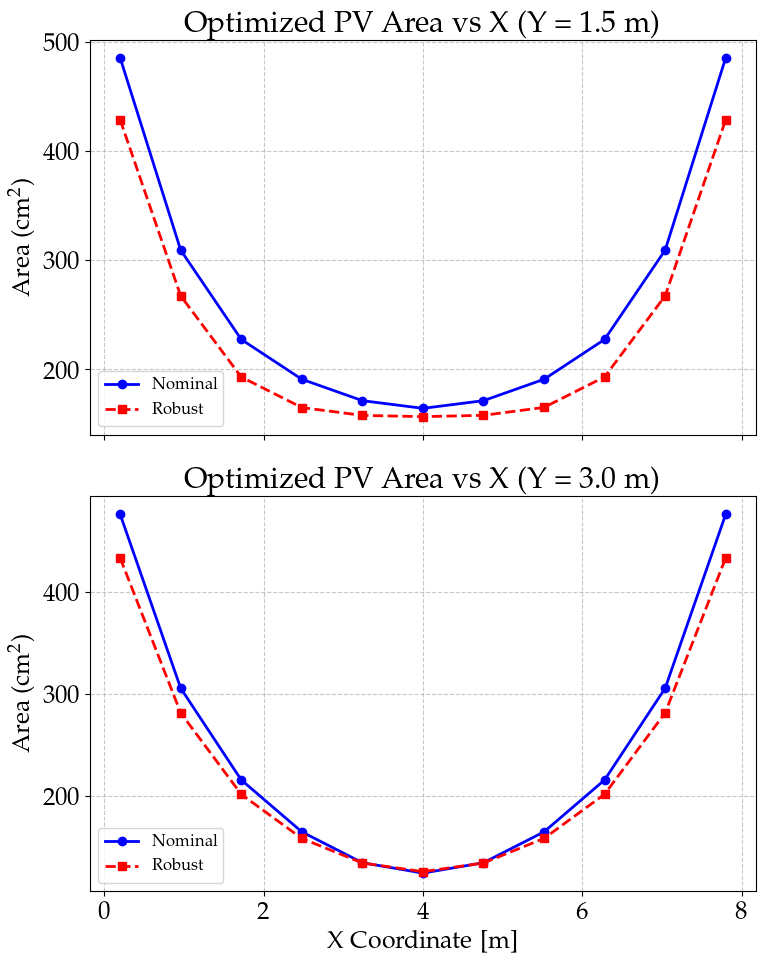

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# 1. Load the results
results_nom = np.load("area_only_cma_results_B1_eight.npy", allow_pickle=True)
results_rob = np.load("robust_minimax_results_B1.npy")  # Columns: [X,Y,Z,...,Area(m2),...]

# 2. Extract X, Y coordinates, and areas
x_coords_nom = np.array([res['pos'][0] for res in results_nom])
y_coords_nom = np.array([res['pos'][1] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

x_coords_rob = results_rob[:, 0]
y_coords_rob = results_rob[:, 1]
areas_rob = results_rob[:, 5] * 1e4  # Convert from m² to cm²

# Get unique Y values
unique_ys = np.unique(y_coords_nom)

# 3. Create the plots (one subplot per Y)
fig, axes = plt.subplots(len(unique_ys), 1, figsize=(8, 5 * len(unique_ys)), sharex=True)

if len(unique_ys) == 1:
    axes = [axes]

for i, y_val in enumerate(unique_ys):
    # Nominal data
    mask_nom = (y_coords_nom == y_val)
    x_nom_y = x_coords_nom[mask_nom]
    areas_nom_y = areas_nom[mask_nom]
    sort_idx_nom = np.argsort(x_nom_y)

    # Robust data
    mask_rob = (y_coords_rob == y_val)
    x_rob_y = x_coords_rob[mask_rob]
    areas_rob_y = areas_rob[mask_rob]
    sort_idx_rob = np.argsort(x_rob_y)

    # Plot both datasets
    axes[i].plot(x_nom_y[sort_idx_nom], areas_nom_y[sort_idx_nom],
                 marker='o', linestyle='-', color='blue', label='Nominal')

    axes[i].plot(x_rob_y[sort_idx_rob], areas_rob_y[sort_idx_rob],
                 marker='s', linestyle='--', color='red', label='Robust')

    axes[i].set_title(rf'Optimized PV Area vs X (Y = {y_val} m)')
    axes[i].set_ylabel(r'Area (cm$^2$)')
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend(fontsize=12)

# X-axis label only for bottom subplot
axes[-1].set_xlabel(r'X Coordinate [m]')

plt.tight_layout()
plt.show()

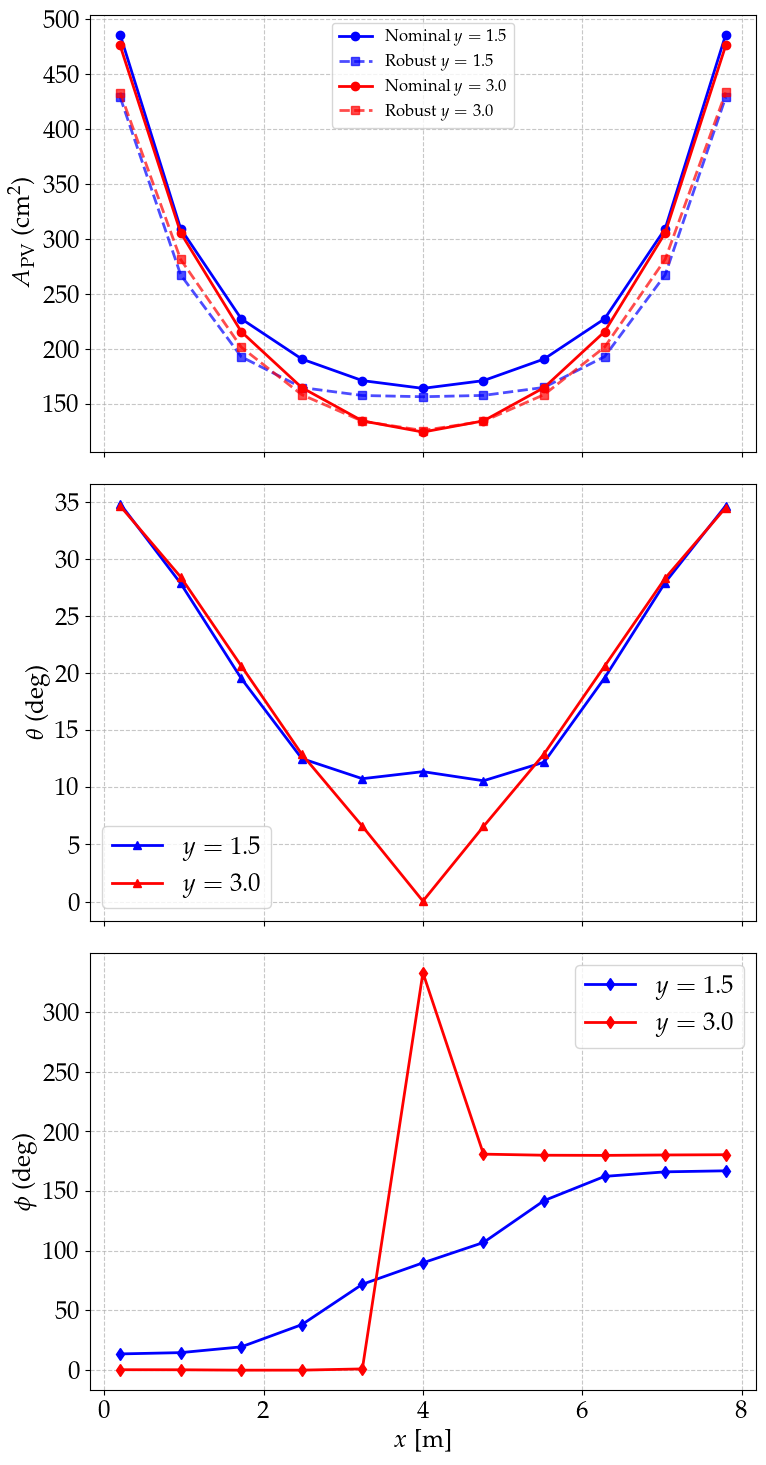

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# -----------------------
# Extract Nominal data
# -----------------------
x_nom = np.array([res['pos'][0] for res in results_nom])
y_nom = np.array([res['pos'][1] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

# -----------------------
# Extract Robust data
# -----------------------
x_rob = results_rob[:,0]
y_rob = results_rob[:,1]

theta_rob = np.degrees(results_rob[:,3])
phi_rob   = np.degrees(results_rob[:,4])
areas_rob = results_rob[:,5] * 1e4  # m² → cm²

# Y values to plot
y_vals = [1.5, 3.0]

# -----------------------
# Figure layout
# -----------------------
fig, axes = plt.subplots(3, 1, figsize=(8,15), sharex=True)

ax_area  = axes[0]
ax_theta = axes[1]
ax_phi   = axes[2]

colors = {1.5: "blue", 3.0: "red"}

# -----------------------
# Plot each Y slice
# -----------------------
for y_val in y_vals:

    mask_nom = np.isclose(y_nom, y_val)
    mask_rob = np.isclose(y_rob, y_val)

    x_nom_y = x_nom[mask_nom]
    areas_nom_y = areas_nom[mask_nom]

    x_rob_y = x_rob[mask_rob]
    areas_rob_y = areas_rob[mask_rob]
    theta_y = theta_rob[mask_rob]
    phi_y = phi_rob[mask_rob]

    sort_nom = np.argsort(x_nom_y)
    sort_rob = np.argsort(x_rob_y)

    # ---- Area ----
    ax_area.plot(
        x_nom_y[sort_nom],
        areas_nom_y[sort_nom],
        'o-',
        color=colors[y_val],
        label=rf'Nominal $y={y_val}$'
    )

    ax_area.plot(
        x_rob_y[sort_rob],
        areas_rob_y[sort_rob],
        's--',
        color=colors[y_val],
        alpha=0.7,
        label=rf'Robust $y={y_val}$'
    )

    # ---- Theta ----
    ax_theta.plot(
        x_rob_y[sort_rob],
        theta_y[sort_rob],
        marker='^',
        linestyle='-',
        color=colors[y_val],
        label=rf'$y={y_val}$'
    )

    # ---- Phi ----
    phi_sorted = phi_y[sort_rob]
    phi_shifted = np.where(phi_sorted > 359.5, phi_sorted - 360, phi_sorted)

    ax_phi.plot(
        x_rob_y[sort_rob],
        phi_shifted,
        marker='d',
        linestyle='-',
        color=colors[y_val],
        label=rf'$y={y_val}$'
    )

# -----------------------
# Labels and formatting
# -----------------------
ax_area.set_ylabel(r'$A_\mathrm{PV}$ (cm$^2$)')
ax_theta.set_ylabel(r'$\theta$ (deg)')
ax_phi.set_ylabel(r'$\phi$ (deg)')
ax_phi.set_xlabel(r'$x$ [m]')

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.7)

ax_area.legend(fontsize=12)
ax_theta.legend()
ax_phi.legend()

plt.tight_layout()
plt.show()

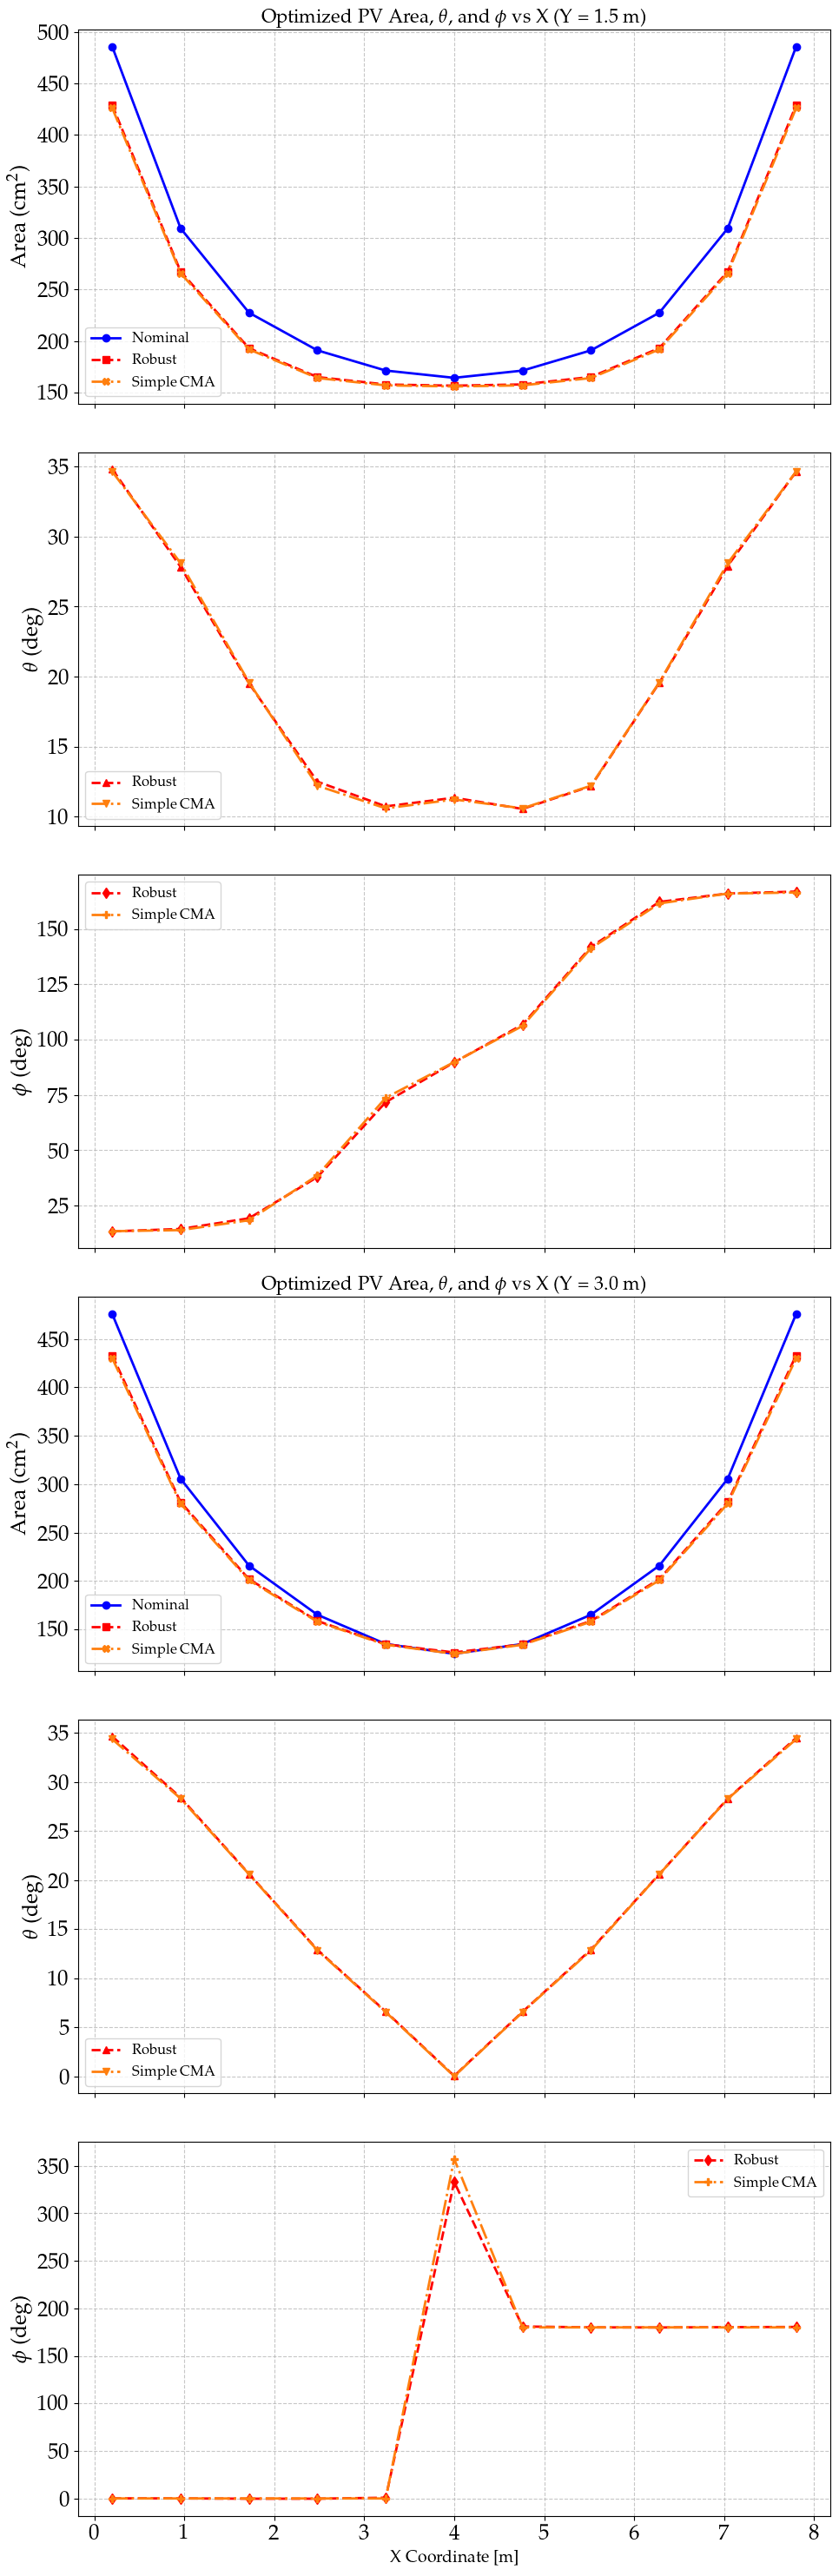

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# 1. Load All 3 Datasets
results_nom = np.load("area_only_cma_results_B1_eight.npy", allow_pickle=True)
results_rob = np.load("robust_minimax_results_B1.npy") 
results_cma = np.load("cma_simple_B1_eight_h.npy", allow_pickle=True)

# 2. Extract Nominal data
x_nom = np.array([res['pos'][0] for res in results_nom])
y_nom = np.array([res['pos'][1] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

# 3. Extract Robust data
x_rob = results_rob[:, 0]
y_rob = results_rob[:, 1]
theta_rob = np.degrees(results_rob[:, 3])  # convert to degrees
phi_rob = np.degrees(results_rob[:, 4])    # convert to degrees
areas_rob = results_rob[:, 5] * 1e4        # m² → cm²

# 4. Extract Simple CMA data
x_cma = np.array([res['pos'][0] for res in results_cma])
y_cma = np.array([res['pos'][1] for res in results_cma])
theta_cma = np.array([res['theta'] for res in results_cma]) # Already in degrees
phi_cma = np.array([res['phi'] for res in results_cma])     # Already in degrees
areas_cma = np.array([res['area_cm2'] for res in results_cma])

# Unique Y values (Assuming based on Nominal)
unique_ys = np.unique(y_nom)

# 3 rows per Y: Area, Theta, Phi
nY = len(unique_ys)
fig, axes = plt.subplots(3 * nY, 1, figsize=(10, 5 * 3 * nY), sharex=True)

if 3 * nY == 1:
    axes = [axes]

for i, y_val in enumerate(unique_ys):

    idx_area = 3*i
    idx_theta = 3*i + 1
    idx_phi = 3*i + 2

    # --- Masks ---
    mask_nom = (y_nom == y_val)
    mask_rob = (y_rob == y_val)
    mask_cma = (y_cma == y_val)

    # --- Nominal ---
    x_nom_y = x_nom[mask_nom]
    areas_nom_y = areas_nom[mask_nom]
    sort_nom = np.argsort(x_nom_y)

    # --- Robust ---
    x_rob_y = x_rob[mask_rob]
    areas_rob_y = areas_rob[mask_rob]
    theta_rob_y = theta_rob[mask_rob]
    phi_rob_y = phi_rob[mask_rob]
    sort_rob = np.argsort(x_rob_y)

    # --- Simple CMA ---
    x_cma_y = x_cma[mask_cma]
    areas_cma_y = areas_cma[mask_cma]
    theta_cma_y = theta_cma[mask_cma]
    phi_cma_y = phi_cma[mask_cma]
    sort_cma = np.argsort(x_cma_y)

    # ==========================
    # ---- 1. Area Plot ----
    # ==========================
    axes[idx_area].plot(x_nom_y[sort_nom], areas_nom_y[sort_nom],
                        marker='o', linestyle='-', color='blue', linewidth=2, label='Nominal')

    axes[idx_area].plot(x_rob_y[sort_rob], areas_rob_y[sort_rob],
                        marker='s', linestyle='--', color='red', linewidth=2, label='Robust')

    axes[idx_area].plot(x_cma_y[sort_cma], areas_cma_y[sort_cma],
                        marker='X', linestyle='-.', color='tab:orange', linewidth=2, label='Simple CMA')

    axes[idx_area].set_title(rf'Optimized PV Area, $\theta$, and $\phi$ vs X (Y = {y_val} m)', fontsize=16)
    axes[idx_area].set_ylabel(r'Area (cm$^2$)')
    axes[idx_area].grid(True, linestyle='--', alpha=0.7)
    axes[idx_area].legend(fontsize=12)

    # ==========================
    # ---- 2. Theta Plot ----
    # ==========================
    axes[idx_theta].plot(x_rob_y[sort_rob], theta_rob_y[sort_rob],
                         marker='^', linestyle='--', color='red', linewidth=2, label='Robust')
                         
    axes[idx_theta].plot(x_cma_y[sort_cma], theta_cma_y[sort_cma],
                         marker='v', linestyle='-.', color='tab:orange', linewidth=2, label='Simple CMA')

    axes[idx_theta].set_ylabel(r'$\theta$ (deg)')
    axes[idx_theta].grid(True, linestyle='--', alpha=0.7)
    axes[idx_theta].legend(fontsize=12)

    # ==========================
    # ---- 3. Phi Plot ----
    # ==========================
    # Robust Phi (with fix)
    phi_rob_sorted = phi_rob_y[sort_rob]
    phi_rob_shifted = np.where(phi_rob_sorted > 359.5, phi_rob_sorted - 360, phi_rob_sorted)
    
    axes[idx_phi].plot(x_rob_y[sort_rob], phi_rob_shifted,
                       marker='d', linestyle='--', color='red', linewidth=2, label='Robust')

    # Simple CMA Phi (with fix)
    phi_cma_sorted = phi_cma_y[sort_cma]
    phi_cma_shifted = np.where(phi_cma_sorted > 359.5, phi_cma_sorted - 360, phi_cma_sorted)
    
    axes[idx_phi].plot(x_cma_y[sort_cma], phi_cma_shifted,
                       marker='P', linestyle='-.', color='tab:orange', linewidth=2, label='Simple CMA')

    axes[idx_phi].set_ylabel(r'$\phi$ (deg)')
    axes[idx_phi].grid(True, linestyle='--', alpha=0.7)
    axes[idx_phi].legend(fontsize=12)

axes[-1].set_xlabel(r'X Coordinate [m]', fontsize=14)

plt.tight_layout()
plt.show()

In [14]:
-(areas_rob[0:11] - areas_nom[0:11])/areas_nom[0:11] * 100

array([ 8.98896567,  7.9045482 ,  6.52401781,  3.89334675,  0.20788802,
       -1.12939158,  0.21713014,  3.88004647,  6.49199158,  7.88105828,
        8.9711283 ])

In [13]:
areas_nom

array([475.80899101, 305.56182172, 215.83795316, 165.02995569,
       134.83233747, 124.68365184, 134.83201341, 165.02995569,
       215.83795316, 305.56182172, 475.808991  , 485.6634086 ,
       309.3744733 , 227.54141239, 191.01916685, 171.41797816,
       164.36100746, 171.39468793, 191.01916685, 227.54141239,
       309.3744733 , 485.6634086 ])

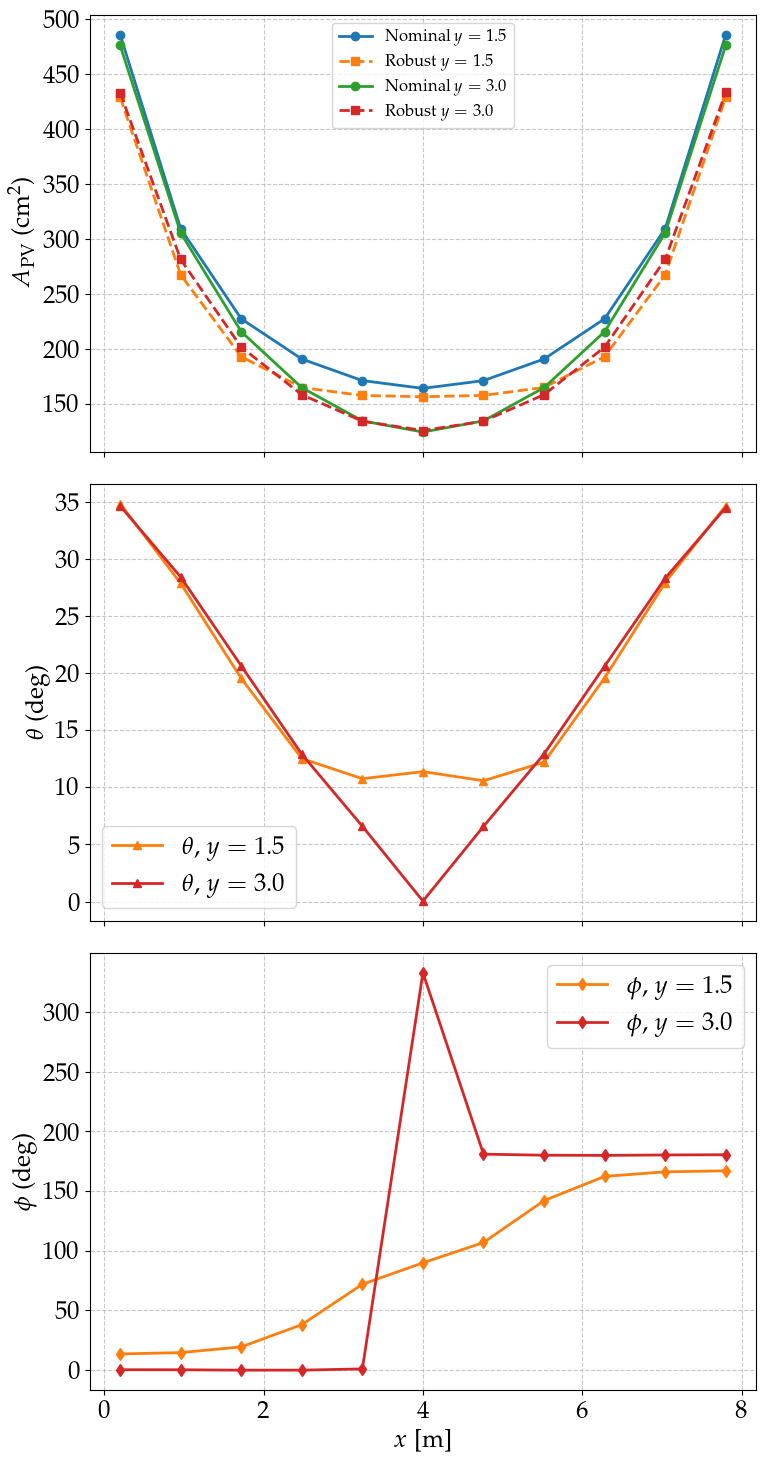

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# -----------------------
# Extract Nominal data
# -----------------------
x_nom = np.array([res['pos'][0] for res in results_nom])
y_nom = np.array([res['pos'][1] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

# -----------------------
# Extract Robust data
# -----------------------
x_rob = results_rob[:, 0]
y_rob = results_rob[:, 1]

theta_rob = np.degrees(results_rob[:, 3])
phi_rob   = np.degrees(results_rob[:, 4])
areas_rob = results_rob[:, 5] * 1e4  # m² → cm²

# Y values to plot
y_vals = [1.5, 3.0]

# Colors for each dataset
colors = {
    ('nom',1.5): 'tab:blue',
    ('rob',1.5): 'tab:orange',
    ('nom',3.0): 'tab:green',
    ('rob',3.0): 'tab:red'
}

# -----------------------
# Figure layout
# -----------------------
fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharex=True)

ax_area  = axes[0]
ax_theta = axes[1]
ax_phi   = axes[2]

# -----------------------
# Plot each Y slice
# -----------------------
for y_val in y_vals:

    mask_nom = np.isclose(y_nom, y_val)
    mask_rob = np.isclose(y_rob, y_val)

    x_nom_y = x_nom[mask_nom]
    areas_nom_y = areas_nom[mask_nom]

    x_rob_y = x_rob[mask_rob]
    areas_rob_y = areas_rob[mask_rob]
    theta_y = theta_rob[mask_rob]
    phi_y = phi_rob[mask_rob]

    sort_nom = np.argsort(x_nom_y)
    sort_rob = np.argsort(x_rob_y)

    # ---- Area ----
    ax_area.plot(
        x_nom_y[sort_nom],
        areas_nom_y[sort_nom],
        marker='o',
        linestyle='-',
        color=colors[('nom',y_val)],
        label=rf'Nominal $y={y_val}$'
    )

    ax_area.plot(
        x_rob_y[sort_rob],
        areas_rob_y[sort_rob],
        marker='s',
        linestyle='--',
        color=colors[('rob',y_val)],
        label=rf'Robust $y={y_val}$'
    )

    # ---- Theta ----
    ax_theta.plot(
        x_rob_y[sort_rob],
        theta_y[sort_rob],
        marker='^',
        linestyle='-',
        color=colors[('rob',y_val)],
        label=rf'$\theta$, $y={y_val}$'
    )

    # ---- Phi ----
    phi_sorted = phi_y[sort_rob]
    phi_shifted = np.where(phi_sorted > 359.5, phi_sorted - 360, phi_sorted)

    ax_phi.plot(
        x_rob_y[sort_rob],
        phi_shifted,
        marker='d',
        linestyle='-',
        color=colors[('rob',y_val)],
        label=rf'$\phi$, $y={y_val}$'
    )

# -----------------------
# Labels and formatting
# -----------------------
ax_area.set_ylabel(r'$A_\mathrm{PV}$ (cm$^2$)')
ax_theta.set_ylabel(r'$\theta$ (deg)')
ax_phi.set_ylabel(r'$\phi$ (deg)')
ax_phi.set_xlabel(r'$x$ [m]')

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.7)

ax_area.legend(fontsize=12)
ax_theta.legend()
ax_phi.legend()

plt.tight_layout()
plt.show()

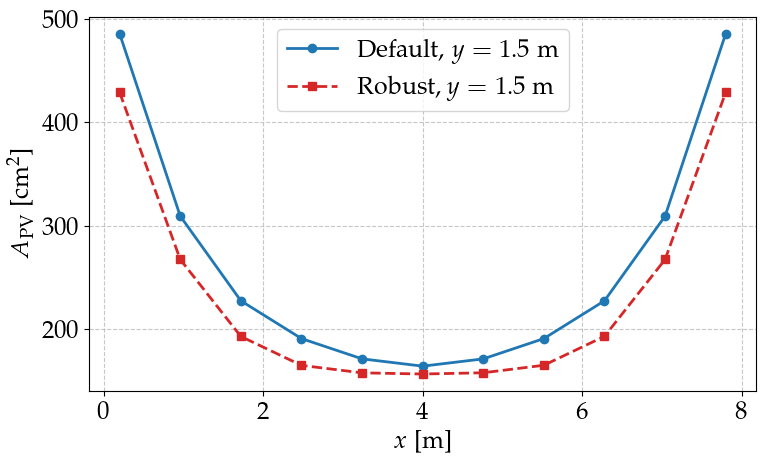

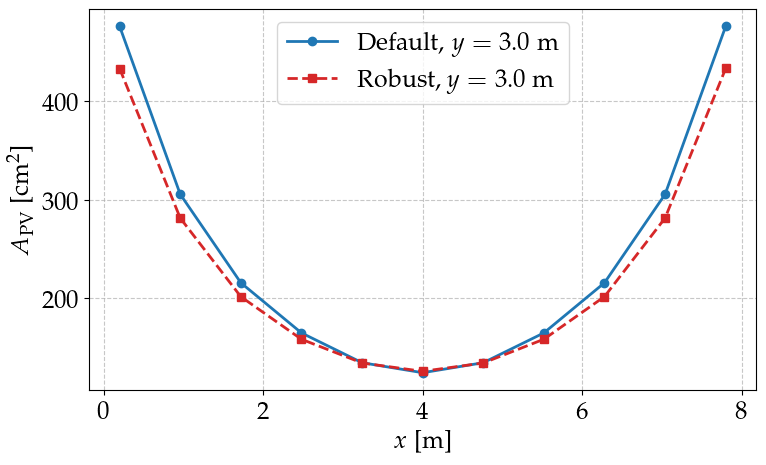

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# -----------------------
# Extract Nominal data
# -----------------------
x_nom = np.array([res['pos'][0] for res in results_nom])
y_nom = np.array([res['pos'][1] for res in results_nom])
areas_nom = np.array([res['area_cm2'] for res in results_nom])

# -----------------------
# Extract Robust data
# -----------------------
x_rob = results_rob[:,0]
y_rob = results_rob[:,1]
areas_rob = results_rob[:,5] * 1e4  # m² → cm²

# Y values
y_vals = [1.5, 3.0]

colors = {
    'nom': 'tab:blue',
    'rob': 'tab:red'
}

# -----------------------
# Generate one plot per Y
# -----------------------
for y_val in y_vals:

    mask_nom = np.isclose(y_nom, y_val)
    mask_rob = np.isclose(y_rob, y_val)

    x_nom_y = x_nom[mask_nom]
    areas_nom_y = areas_nom[mask_nom]

    x_rob_y = x_rob[mask_rob]
    areas_rob_y = areas_rob[mask_rob]

    sort_nom = np.argsort(x_nom_y)
    sort_rob = np.argsort(x_rob_y)

    fig, ax = plt.subplots(figsize=(8,5))

    # Nominal
    ax.plot(
        x_nom_y[sort_nom],
        areas_nom_y[sort_nom],
        marker='o',
        linestyle='-',
        color=colors['nom'],
        label=rf'Default, $y={y_val}$ m'
    )

    # Robust
    ax.plot(
        x_rob_y[sort_rob],
        areas_rob_y[sort_rob],
        marker='s',
        linestyle='--',
        color=colors['rob'],
        label=rf'Robust, $y={y_val}$ m'
    )

    ax.set_xlabel(r'$x$ [m]')
    ax.set_ylabel(r'$A_\mathrm{PV}$ [cm$^2$]')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

    plt.tight_layout()

    filename = f"area_B1_{str(y_val).replace('.', 'p')}.pdf"
    plt.savefig(filename)
    plt.show()
    plt.close(fig)

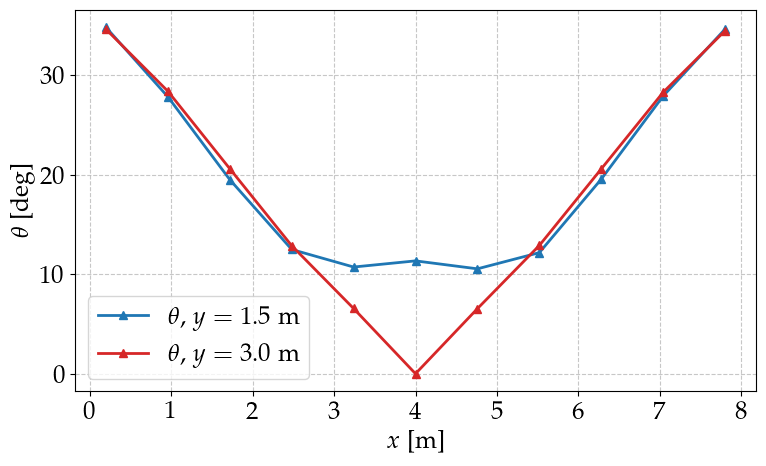

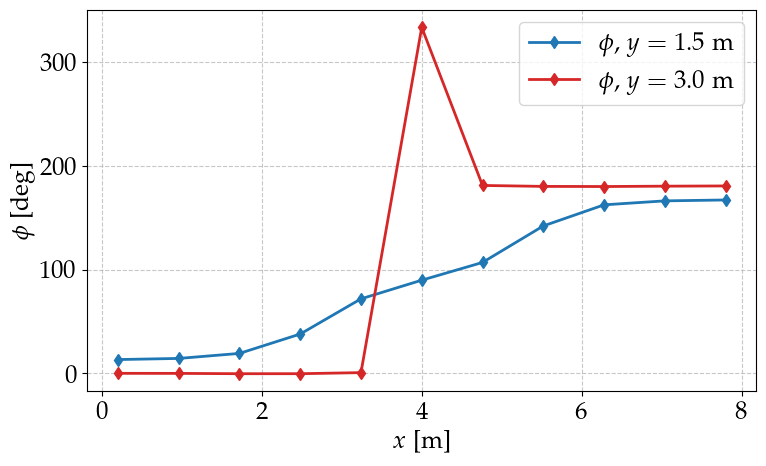

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 18,
    "lines.linewidth": 2,
})

# -----------------------
# Extract Robust data
# -----------------------
x_rob = results_rob[:, 0]
y_rob = results_rob[:, 1]

theta_rob = np.degrees(results_rob[:, 3])
phi_rob   = np.degrees(results_rob[:, 4])

# Y values to plot
y_vals = [1.5, 3.0]

# Colors per Y
colors = {1.5: 'tab:blue', 3.0: 'tab:red'}

# -----------------------
# THETA PLOT (both Y on one plot)
# -----------------------
fig, ax_theta = plt.subplots(figsize=(8,5))
for y_val in y_vals:
    mask = np.isclose(y_rob, y_val)
    x_y = x_rob[mask]
    theta_y = theta_rob[mask]
    sort_idx = np.argsort(x_y)

    ax_theta.plot(
        x_y[sort_idx],
        theta_y[sort_idx],
        marker='^',
        linestyle='-',
        color=colors[y_val],
        label=rf'$\theta$, $y={y_val}$ m'
    )

ax_theta.set_xlabel(r'$x$ [m]')
ax_theta.set_ylabel(r'$\theta$ [deg]')
ax_theta.grid(True, linestyle='--', alpha=0.7)
ax_theta.legend()
plt.tight_layout()
plt.savefig("theta_B1.pdf")
plt.show()
plt.close(fig)

# -----------------------
# PHI PLOT (both Y on one plot)
# -----------------------
fig, ax_phi = plt.subplots(figsize=(8,5))
for y_val in y_vals:
    mask = np.isclose(y_rob, y_val)
    x_y = x_rob[mask]
    phi_y = phi_rob[mask]
    sort_idx = np.argsort(x_y)

    # Shift angles > 359.5 to negative for continuity
    phi_sorted = phi_y[sort_idx]
    phi_shifted = np.where(phi_sorted > 359.5, phi_sorted - 360, phi_sorted)

    ax_phi.plot(
        x_y[sort_idx],
        phi_shifted,
        marker='d',
        linestyle='-',
        color=colors[y_val],
        label=rf'$\phi$, $y={y_val}$ m'
    )

ax_phi.set_xlabel(r'$x$ [m]')
ax_phi.set_ylabel(r'$\phi$ [deg]')
ax_phi.grid(True, linestyle='--', alpha=0.7)
ax_phi.legend()
plt.tight_layout()
plt.savefig("phi_B1.pdf")
plt.show()
plt.close(fig)

In [48]:
(areas_nom[0:11] - areas_rob[0:11])/areas_rob[0:11] * 100

array([ 9.87678663,  8.58299519,  6.97935197,  4.05106891,  0.20832109,
       -1.11677878,  0.21760262,  4.03667119,  6.94271185,  8.55530701,
        9.85525595])

In [49]:
(areas_nom[11:] - areas_rob[11:])/areas_rob[11:] * 100

array([13.23800544, 15.66926184, 17.84024531, 15.69530679,  8.56620324,
        4.84890909,  8.50127396, 15.60528447, 17.78911382, 15.67130248,
       13.25486694])

In [50]:
areas_nom[11:]


array([485.6634086 , 309.3744733 , 227.54141239, 191.01916685,
       171.41797816, 164.36100746, 171.39468793, 191.01916685,
       227.54141239, 309.3744733 , 485.6634086 ])